In [17]:
import pyarrow.feather as feather
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from item_classifier import *
from plots import *

In [18]:
table = feather.read_table('../dataset/data_andre_fulfilled.feather', memory_map=True) 
df= table.to_pandas() 
df.head()

,item_id,store_id,date,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,...,promo_type_DISC,promo_value_DISC,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE
0,27,6269,2021-01-23,8.0,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,27,6269,2021-01-24,14.0,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,27,6269,2021-01-25,8.0,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,27,6269,2021-01-26,5.0,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,27,6269,2021-01-27,8.0,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
df_indexed = df.copy()
df_indexed["date"] = pd.to_datetime(df_indexed["date"])
df_indexed = df_indexed.set_index("date").sort_index()
df_indexed.head()

,item_id,store_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,...,promo_type_DISC,promo_value_DISC,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE
date,,,,,,,,,,,,,,,,,,,,,
2021-01-23,27,6269,8.0,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-23,113613,6269,3.0,refrig dsrts,pos subd dairy other,pos dept dairy,other dairy,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-23,13108,6269,4.0,cream chs,pos subd dairy other,pos dept dairy,other dairy,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-23,53665,6269,1.0,sparkling seltzer mixer,pos subd grocery other,pos dept grocery,water/isotonics,0.0,0.0,0.0,...,0.0,0.0,1.0,0.1304,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-23,31242,6269,0.0,None,None,None,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
'''
# Classify all items
df_classified, summary = classify_items(
    df_indexed,
    seasonal_strength_threshold=0.3,    # Adjust based on your domain
    cv_threshold=0.5,                    # Adjust for intermittence detection
    initial_gap_fraction=0.2,            # 20% gap at start = new item
)

# Display summary
print("Label Distribution:")
print(summary['label_counts'])
print("\n" + "="*60)

df_classified.head()
'''


'\n# Classify all items\ndf_classified, summary = classify_items(\n    df_indexed,\n    seasonal_strength_threshold=0.3,    # Adjust based on your domain\n    cv_threshold=0.5,                    # Adjust for intermittence detection\n    initial_gap_fraction=0.2,            # 20% gap at start = new item\n)\n\n# Display summary\nprint("Label Distribution:")\nprint(summary[\'label_counts\'])\nprint("\n" + "="*60)\n\ndf_classified.head()\n'


## Classification Parameters Guide

The classifier uses three main parameters to categorize items:

### 1. `seasonal_strength_threshold` (default: 0.3)
- **What**: Strength of periodicity/seasonality in sales pattern (0-1 scale)
- **Higher values**: More strict seasonality detection
- **Lower values**: Easier to detect seasonal patterns
- **From document**: Items with sales/non-sales cycles that are regular and periodic

### 2. `cv_threshold` (default: 0.5)  
- **What**: Coefficient of Variation in cycle intervals
- **Higher values**: Allow more variability in intervals (more "erratic")
- **Lower values**: Stricter intermittence detection
- **From document**: Intermittent items have intervals that "don't share any common pattern"

### 3. `initial_gap_fraction` (default: 0.2)
- **What**: Fraction of zero-sales at the beginning (0-1 scale)
- **Higher values**: Allow longer initial gaps
- **Lower values**: Stricter new item detection
- **From document**: New items have "meaningful non-sales cycle at the beginning"

## Tuning Tips
- Start with defaults, then adjust based on your visualization results
- If too many items are "seasonal" → increase `seasonal_strength_threshold`
- If too many items are "intermittent" → increase `cv_threshold`
- If too many items are "new" → increase `initial_gap_fraction`


In [21]:
#plot_label_distribution(summary["label_counts"]);

In [22]:
df_classified, labels_df, summary = classify_items_adi_cv(df_indexed)


In [23]:
df_indexed.head()

,item_id,store_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,...,promo_type_DISC,promo_value_DISC,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE
date,,,,,,,,,,,,,,,,,,,,,
2021-01-23,27,6269,8.0,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-23,113613,6269,3.0,refrig dsrts,pos subd dairy other,pos dept dairy,other dairy,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-23,13108,6269,4.0,cream chs,pos subd dairy other,pos dept dairy,other dairy,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-23,53665,6269,1.0,sparkling seltzer mixer,pos subd grocery other,pos dept grocery,water/isotonics,0.0,0.0,0.0,...,0.0,0.0,1.0,0.1304,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-23,31242,6269,0.0,None,None,None,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
df_classified

,item_id,store_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,...,promo_value_DISC,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE,item_label
date,,,,,,,,,,,,,,,,,,,,,
2021-01-23,27,6269,8.0,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0.0,0.0,0.0,...,0.0000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,seasonal
2021-01-23,113613,6269,3.0,refrig dsrts,pos subd dairy other,pos dept dairy,other dairy,0.0,0.0,0.0,...,0.0000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,lumpy
2021-01-23,13108,6269,4.0,cream chs,pos subd dairy other,pos dept dairy,other dairy,0.0,0.0,0.0,...,0.0000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,seasonal
2021-01-23,53665,6269,1.0,sparkling seltzer mixer,pos subd grocery other,pos dept grocery,water/isotonics,0.0,0.0,0.0,...,0.0000,1.0,0.1304,0.0,0.0,0.0,0.0,0.0,0.0,seasonal
2021-01-23,31242,6269,0.0,None,None,None,None,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,lumpy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-02-22,162819,6269,3.0,rte cereal,pos subd grocery other,pos dept grocery,breakfast,0.0,0.0,0.0,...,0.0000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,lumpy
2023-02-22,219,6269,4.0,milknplant based bevs,pos subd dairy other,pos dept dairy,other dairy,0.0,0.0,0.0,...,0.0000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,seasonal
2023-02-22,219733,6269,3.0,rte cereal,pos subd grocery other,pos dept grocery,breakfast,0.0,0.0,0.0,...,0.0000,0.0,0.0000,0.0,0.0,1.0,0.0,0.0,0.0,lumpy



Detailed Classification Distribution:
Total items: 1427

Breakdown:
  seasonal    :    905 items ( 63.4%)
  lumpy       :    452 items ( 31.7%)
  smooth      :     67 items (  4.7%)
  intermittent:      3 items (  0.2%)


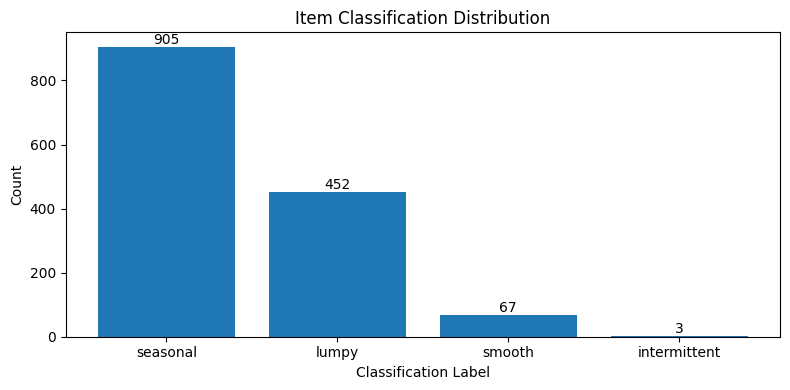

In [25]:
plot_label_distribution(summary['label_counts']);

Product ID: 151825
Date range: 2021-01-23 00:00:00 to 2023-02-22 00:00:00
Total records: 761
Non-zero sales: 550


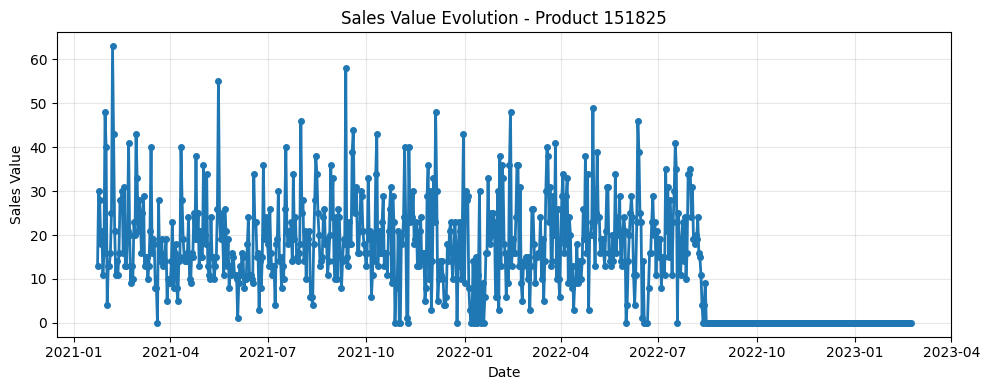

(<Axes: title={'center': 'Sales Value Evolution - Product 151825'}, xlabel='Date', ylabel='Sales Value'>,
           date  value
 0   2021-01-23   13.0
 1   2021-01-24   30.0
 2   2021-01-25   28.0
 3   2021-01-26   18.0
 4   2021-01-27   21.0
 ..         ...    ...
 756 2023-02-18    0.0
 757 2023-02-19    0.0
 758 2023-02-20    0.0
 759 2023-02-21    0.0
 760 2023-02-22    0.0
 
 [761 rows x 2 columns],
 {'product_id': 151825,
  'date_min': Timestamp('2021-01-23 00:00:00'),
  'date_max': Timestamp('2023-02-22 00:00:00'),
  'total_records': 761,
  'non_zero_sales': 550,
  'describe': count    761.000000
  mean      13.929041
  std       11.975752
  min        0.000000
  25%        0.000000
  50%       14.000000
  75%       21.000000
  max       63.000000
  Name: value, dtype: float64})

In [26]:
plot_product_value_evolution(df_indexed, selected_product=151825, date_col=None, value_col='value')


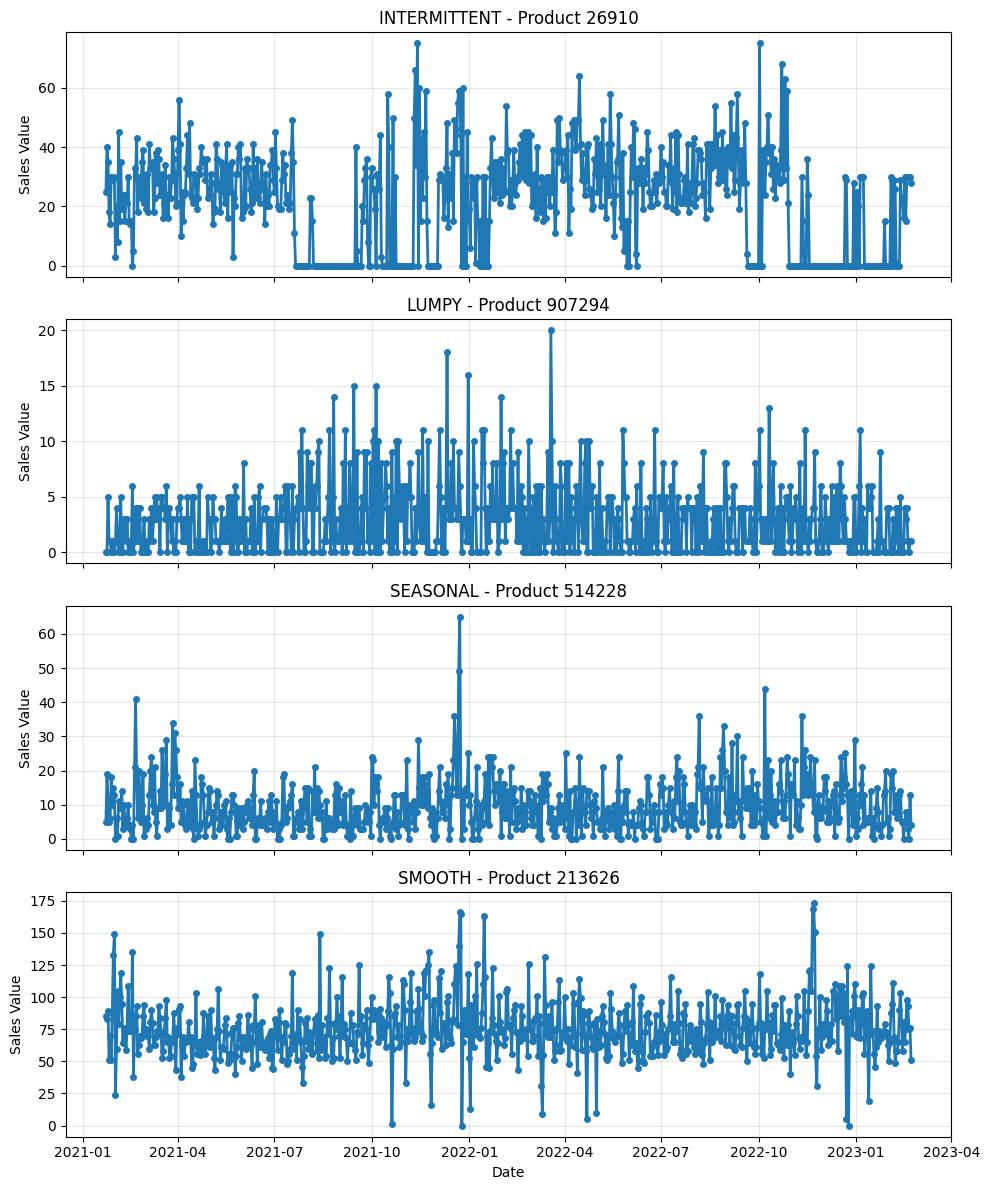

In [27]:
plot_random_sample_per_label(df_indexed, df_classified, date_col=None, seed=None);

In [28]:
df_classified[(df_classified['item_label']=='seasonal') | (df_classified['item_label']=='smooth')]

,item_id,store_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,...,promo_value_DISC,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE,item_label
date,,,,,,,,,,,,,,,,,,,,,
2021-01-23,27,6269,8.0,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0.0,0.0,0.0,...,0.0000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,seasonal
2021-01-23,13108,6269,4.0,cream chs,pos subd dairy other,pos dept dairy,other dairy,0.0,0.0,0.0,...,0.0000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,seasonal
2021-01-23,53665,6269,1.0,sparkling seltzer mixer,pos subd grocery other,pos dept grocery,water/isotonics,0.0,0.0,0.0,...,0.0000,1.0,0.1304,0.0,0.0,0.0,0.0,0.0,0.0,seasonal
2021-01-23,742,6269,4.0,refrigerated baked gds,pos subd dairy other,pos dept dairy,other dairy,0.0,0.0,0.0,...,0.0000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,seasonal
2021-01-23,65948,6269,11.0,yogurt,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0.0,0.0,0.0,...,0.2603,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,seasonal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-02-22,113639,6269,3.0,refrig dsrts,pos subd dairy other,pos dept dairy,other dairy,0.0,0.0,0.0,...,0.0000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,seasonal
2023-02-22,9284,6269,3.0,dy non dy crm,pos subd dairy other,pos dept dairy,other dairy,0.0,0.0,0.0,...,0.0000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,seasonal
2023-02-22,606383,6269,6.0,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0.0,0.0,0.0,...,0.0000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,seasonal


In [29]:
def select_best_seasonal_smooth(df, top_n=100, max_zero_rate=0.2, sales_col='value', item_col='item_id', label_col='item_label', labels=('seasonal','smooth'), by='total_sales'):
    # filter seasonal / smooth
    df_sub = df[df[label_col].isin(labels)].copy()

    # ensure numeric sales
    df_sub[sales_col] = pd.to_numeric(df_sub[sales_col], errors='coerce').fillna(0)

    # compute metrics per item
    agg = df_sub.groupby(item_col).agg(
        days_observed=('date', 'nunique'),
        total_sales=(sales_col, 'sum'),
        mean_sales=(sales_col, 'mean'),
        median_sales=(sales_col, 'median'),
        zeros=(sales_col, lambda x: (x==0).sum()),
        obs_count=(sales_col, 'count')
    ).reset_index()

    agg['zero_rate'] = agg['zeros'] / agg['obs_count']
    agg['nonzero_mean'] = agg.apply(lambda r: r['total_sales'] / max(1, r['obs_count'] - r['zeros']), axis=1)

    # filter by zero rate
    agg = agg[agg['zero_rate'] <= max_zero_rate]

    # choose sort key
    if by == 'total_sales':
        agg = agg.sort_values('total_sales', ascending=False)
    elif by == 'mean_sales':
        agg = agg.sort_values('mean_sales', ascending=False)
    elif by == 'nonzero_mean':
        agg = agg.sort_values('nonzero_mean', ascending=False)
    else:
        raise ValueError("by must be 'total_sales', 'mean_sales' or 'nonzero_mean'")

    # take top_n items and return original rows for those items
    top_items = agg.head(top_n)[item_col].tolist()
    return df_sub[df_sub[item_col].isin(top_items)].copy(), agg.loc[agg[item_col].isin(top_items)]

# Example usage:
# subset_rows, top_summary = select_best_seasonal_smooth(df_classified, top_n=50, max_zero_rate=0.15)

In [30]:
# Show a few example products for each ADI-CV category
n_examples = 5
for cat in ["smooth", "seasonal", "intermittent", "lumpy"]:
    items_in_cat = labels_df.loc[labels_df["label"] == cat].sort_values("total_periods", ascending=False)
    print(f"\n=== {cat.upper()} ({len(items_in_cat)} items) ===")
    display(items_in_cat.head(n_examples))



=== SMOOTH (67 items) ===


,item_id,label,adi,cv,non_zero_periods,total_periods
10,113887,smooth,1.071831,0.435624,710,761
985,213631,smooth,1.002635,0.321580,759,761
676,962444,smooth,1.056944,0.487799,720,761
684,324,smooth,1.087143,0.479208,700,761
689,57364,smooth,1.102899,0.486542,690,761



=== SEASONAL (905 items) ===


,item_id,label,adi,cv,non_zero_periods,total_periods
0,27,seasonal,1.007947,0.503782,755,761
977,3720,seasonal,1.104499,0.704915,689,761
937,962963,seasonal,1.296422,0.707852,587,761
938,545599,seasonal,1.020107,0.644747,746,761
940,266558,seasonal,1.151286,0.604801,661,761



=== INTERMITTENT (3 items) ===


,item_id,label,adi,cv,non_zero_periods,total_periods
75,100472,intermittent,1.330420,0.487153,572,761
115,962210,intermittent,1.346903,0.477352,565,761
194,26910,intermittent,1.376130,0.376928,553,761



=== LUMPY (452 items) ===


,item_id,label,adi,cv,non_zero_periods,total_periods
1,113613,lumpy,1.381125,0.614323,551,761
917,153307,lumpy,1.474806,0.707728,516,761
1000,268649,lumpy,1.509921,0.669920,504,761
998,96792,lumpy,1.409259,0.755653,540,761
996,285024,lumpy,1.486328,0.636179,512,761


In [31]:
# Export item_id -> ADI/CV label (smooth / seasonal / intermittent / lumpy) to CSV
df_labels_adi_cv = (
    labels_df[["item_id", "label"]]
    .drop_duplicates(subset="item_id")
    .sort_values("item_id")
    .reset_index(drop=True)
)

out_path = "../dataset/df_labels_adi_cv.csv"
df_labels_adi_cv.to_csv(out_path, index=False)
print(f"Saved {len(df_labels_adi_cv)} rows -> {out_path}")
print(df_labels_adi_cv["label"].value_counts())
df_labels_adi_cv.head()


Saved 1427 rows -> ../dataset/df_labels_adi_cv.csv
label
seasonal        905
lumpy           452
smooth           67
intermittent      3
Name: count, dtype: int64


,item_id,label
0,27,seasonal
1,55,lumpy
2,71,seasonal
3,116,smooth
4,128,seasonal


In [32]:
 
# ── Export smooth-only products to feather ───────────────────────────────
smooth_ids = labels_df.loc[labels_df["label"] == "smooth", "item_id"].unique()
 
# Filter the full indexed dataframe to smooth items only, reset index so
# 'date' becomes a regular column again (feather doesn't support DatetimeIndex)
df_smooth = (
    df_indexed[df_indexed["item_id"].isin(smooth_ids)]
    .reset_index()          # moves 'date' back to a column
)
 
out_feather = "../dataset/data_smooth.feather"
df_smooth.to_feather(out_feather)
 
print(f"Smooth products : {len(smooth_ids)}")
print(f"Rows saved      : {len(df_smooth)}")
print(f"Saved to        : {out_feather}")
df_smooth.head()
 

Smooth products : 67
Rows saved      : 50987
Saved to        : ../dataset/data_smooth.feather


,date,item_id,store_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,...,promo_type_DISC,promo_value_DISC,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE
0,2021-01-23,113887,6269,13.0,yogurt,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0.0,0.0,...,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
1,2021-01-23,959943,6269,8.0,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0.0,0.0,...,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
2,2021-01-23,9464,6269,9.0,dy non dy crm,pos subd dairy other,pos dept dairy,other dairy,0.0,0.0,...,0.0,0.0,1.0,0.0178,0.0,0.0,0.0,0.0,0.0,0.0
3,2021-01-23,514230,6269,10.0,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0.0,0.0,...,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
4,2021-01-23,116,6269,16.0,dairy cream,pos subd dairy other,pos dept dairy,other dairy,0.0,0.0,...,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
